# Include Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Loading dataset

In [2]:
dataset = pd.read_csv("/kaggle/input/samplesuperstore/SampleSuperstore.csv")

In [3]:
dataset.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
dataset.shape

(9993, 13)

In [5]:
dataset.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9993 non-null   object 
 1   Segment       9993 non-null   object 
 2   Country       9993 non-null   object 
 3   City          9993 non-null   object 
 4   State         9993 non-null   object 
 5   Postal Code   9993 non-null   int64  
 6   Region        9993 non-null   object 
 7   Category      9993 non-null   object 
 8   Sub-Category  9993 non-null   object 
 9   Sales         9993 non-null   float64
 10  Quantity      9993 non-null   int64  
 11  Discount      9993 non-null   float64
 12  Profit        9993 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.0+ KB


In [7]:
dataset.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9993.000000,9993.000000,9993.000000,9993.000000,9993.000000
mean,55186.627539,229.856670,3.789753,0.156218,28.652464
std,32063.103801,623.276273,2.225149,0.206456,234.271411
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728000
50%,56301.000000,54.480000,3.000000,0.200000,8.662000
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
dataset.corr()

/tmp/ipykernel_20/2191645083.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dataset.corr()


,Postal Code,Sales,Quantity,Discount,Profit
Postal Code,1.000000,-0.023858,0.012856,0.058537,-0.029985
Sales,-0.023858,1.000000,0.200803,-0.028189,0.479065
Quantity,0.012856,0.200803,1.000000,0.008563,0.066271
Discount,0.058537,-0.028189,0.008563,1.000000,-0.219480
Profit,-0.029985,0.479065,0.066271,-0.219480,1.000000


array([[<Axes: title={'center': 'Postal Code'}>,
        <Axes: title={'center': 'Sales'}>],
       [<Axes: title={'center': 'Quantity'}>,
        <Axes: title={'center': 'Discount'}>],
       [<Axes: title={'center': 'Profit'}>, <Axes: >]], dtype=object)

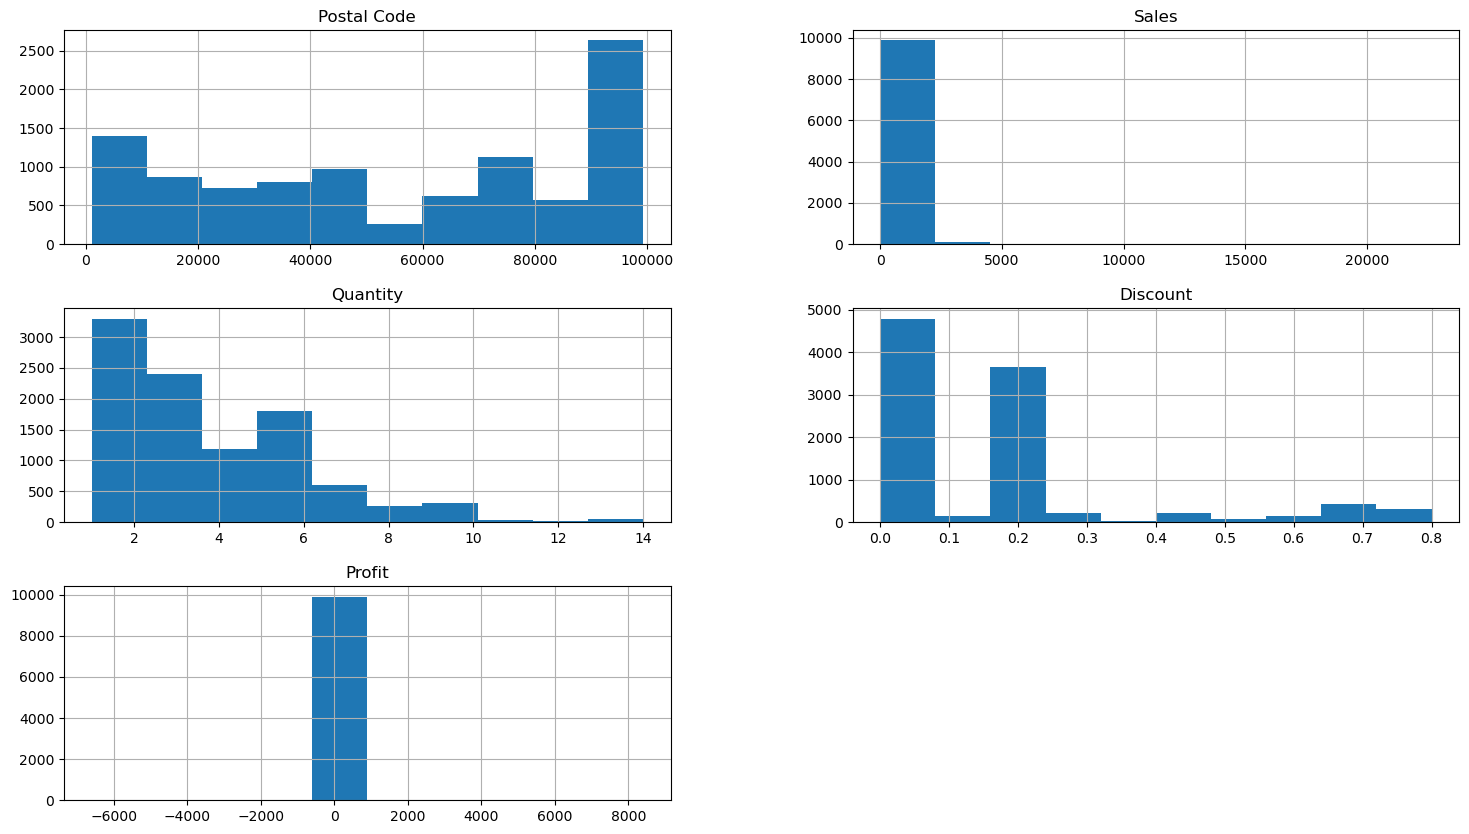

In [9]:
dataset.hist(bins=10, figsize=(18,10))

/tmp/ipykernel_20/2571642465.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(dataset.corr(), annot = True)


<Axes: >

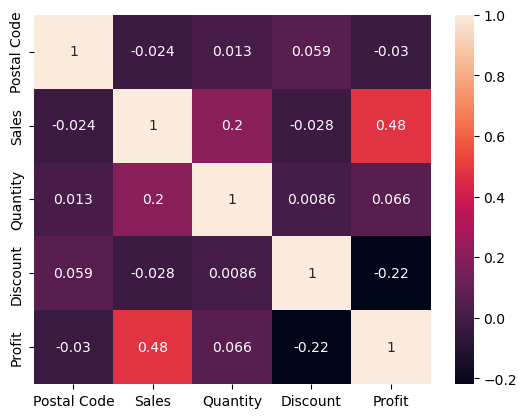

In [10]:
sns.heatmap(dataset.corr(), annot = True)

# 1. Cities

In [11]:
dataset["City"].unique()

array(['Henderson', 'Los Angeles', 'Fort Lauderdale', 'Concord',
       'Seattle', 'Fort Worth', 'Madison', 'West Jordan', 'San Francisco',
       'Fremont', 'Philadelphia', 'Orem', 'Houston', 'Richardson',
       'Naperville', 'Melbourne', 'Eagan', 'Westland', 'Dover',
       'New Albany', 'New York City', 'Troy', 'Chicago', 'Gilbert',
       'Springfield', 'Jackson', 'Memphis', 'Decatur', 'Durham',
       'Columbia', 'Rochester', 'Minneapolis', 'Portland', 'Saint Paul',
       'Aurora', 'Charlotte', 'Orland Park', 'Urbandale', 'Columbus',
       'Bristol', 'Wilmington', 'Bloomington', 'Phoenix', 'Roseville',
       'Independence', 'Pasadena', 'Newark', 'Franklin', 'Scottsdale',
       'San Jose', 'Edmond', 'Carlsbad', 'San Antonio', 'Monroe',
       'Fairfield', 'Grand Prairie', 'Redlands', 'Hamilton', 'Westfield',
       'Akron', 'Denver', 'Dallas', 'Whittier', 'Saginaw', 'Medina',
       'Dublin', 'Detroit', 'Tampa', 'Santa Clara', 'Lakeville',
       'San Diego', 'Brentwood', 'Cha

In [12]:
cities_profit=pd.DataFrame(dataset.groupby("City")["Profit"].sum())
cities_profit=cities_profit.sort_values(by="Profit",ascending=False)
cities_profit.head(10)

,Profit
City,
New York City,62036.9837
Los Angeles,30440.7579
Seattle,29156.0967
San Francisco,17507.3854
Detroit,13181.7908
Lafayette,10018.3876
Jackson,7581.6828
Atlanta,6993.6629
Minneapolis,6824.5846


In [13]:
cities_sale=pd.DataFrame(dataset.groupby("City")["Sales"].sum())
cities_sale=cities_sale.sort_values(by="Sales",ascending=False)
cities_sale.head(10)

,Sales
City,
New York City,256368.1610
Los Angeles,175851.3410
Seattle,119540.7420
San Francisco,112669.0920
Philadelphia,109077.0130
Houston,64504.7604
Chicago,48539.5410
San Diego,47521.0290
Jacksonville,44713.1830


# 2. States

In [14]:
dataset["State"].unique()

array(['Kentucky', 'California', 'Florida', 'North Carolina',
       'Washington', 'Texas', 'Wisconsin', 'Utah', 'Nebraska',
       'Pennsylvania', 'Illinois', 'Minnesota', 'Michigan', 'Delaware',
       'Indiana', 'New York', 'Arizona', 'Virginia', 'Tennessee',
       'Alabama', 'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio',
       'Missouri', 'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut',
       'New Jersey', 'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Montana', 'New Hampshire', 'Maryland',
       'District of Columbia', 'Kansas', 'Vermont', 'Maine',
       'South Dakota', 'Idaho', 'North Dakota', 'Wyoming',
       'West Virginia'], dtype=object)

In [15]:
state_profit=pd.DataFrame(dataset.groupby("State")["Profit"].sum())
state_profit=state_profit.sort_values(by="Profit",ascending=False)
state_profit.head(10)

,Profit
State,
California,76308.4391
New York,74038.5486
Washington,33402.6517
Michigan,24463.1876
Virginia,18597.9504
Indiana,18382.9363
Georgia,16250.0433
Kentucky,11199.6966
Minnesota,10823.1874


# 3. Category & Sub-Category

In [16]:
dataset["Category"].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [17]:
cat_profit=pd.DataFrame(dataset.groupby("Category")["Profit"].sum())
cat_profit=cat_profit.sort_values(by="Profit",ascending=False)
cat_profit

,Profit
Category,
Technology,145454.9481
Office Supplies,122417.8528
Furniture,18451.2728


<Axes: xlabel='Category'>

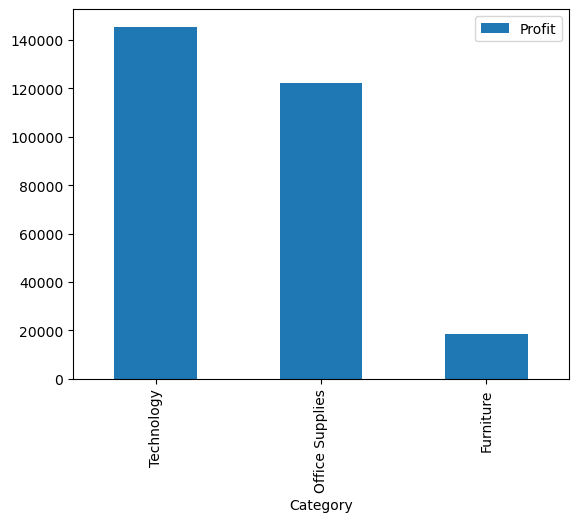

In [18]:
cat_profit.plot(kind = 'bar')

In [19]:
cat_sale=pd.DataFrame(dataset.groupby("Category")["Sales"].sum())
cat_sale=cat_sale.sort_values(by="Sales",ascending=False)
cat_sale

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,718803.8720


<Axes: xlabel='Category'>

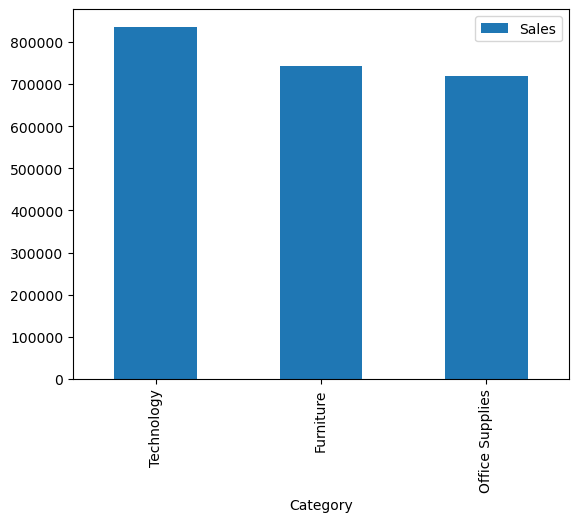

In [20]:
cat_sale.plot(kind = 'bar')

In [21]:
dataset["Sub-Category"].unique()

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper',
       'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines',
       'Copiers'], dtype=object)

In [22]:
subcat_profit=pd.DataFrame(dataset.groupby("Sub-Category")["Profit"].sum())
subcat_profit=subcat_profit.sort_values(by="Profit",ascending=False)
subcat_profit.head(10)

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18065.0574
Furnishings,13059.1436


<Axes: xlabel='Sub-Category'>

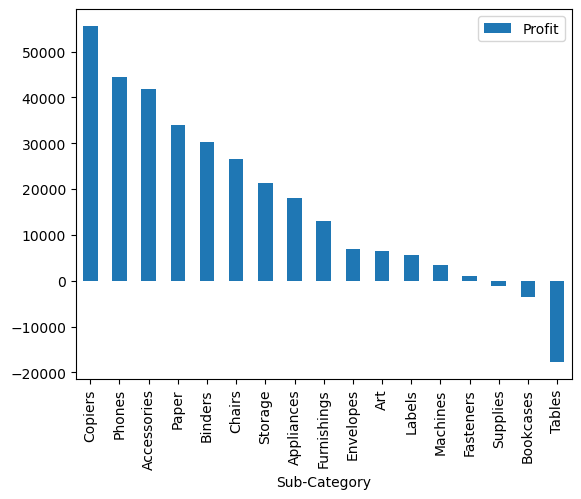

In [23]:
subcat_profit.plot(kind = 'bar')

In [24]:
subcat_sale=pd.DataFrame(dataset.groupby("Sub-Category")["Sales"].sum())
subcat_sale=subcat_sale.sort_values(by="Sales",ascending=False)
subcat_sale.head(10)

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


<Axes: xlabel='Sub-Category'>

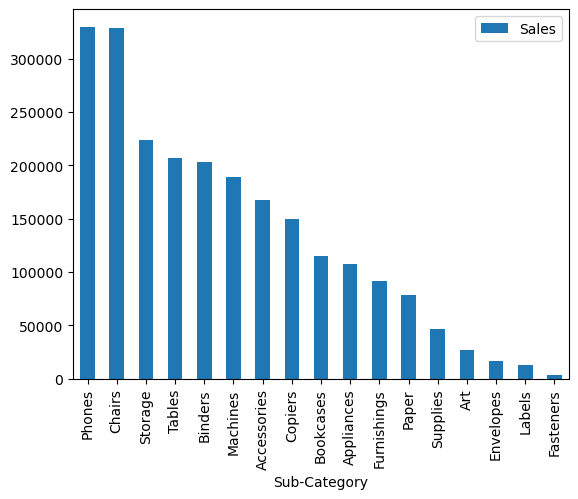

In [25]:
subcat_sale.plot(kind = 'bar')

In [26]:
subcat_quant=pd.DataFrame(dataset.groupby("Sub-Category")["Quantity"].sum())
subcat_quant=subcat_quant.sort_values(by="Quantity",ascending=False)
subcat_quant.head(10)

,Quantity
Sub-Category,
Binders,5974
Paper,5178
Furnishings,3563
Phones,3289
Storage,3158
Art,3000
Accessories,2976
Chairs,2356
Appliances,1727


<Axes: xlabel='Sub-Category'>

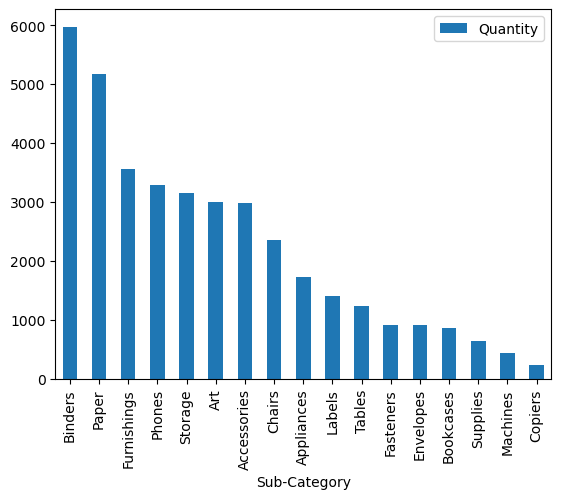

In [27]:
subcat_quant.plot(kind = 'bar')

# 4. Segment

<Axes: xlabel='Segment', ylabel='count'>

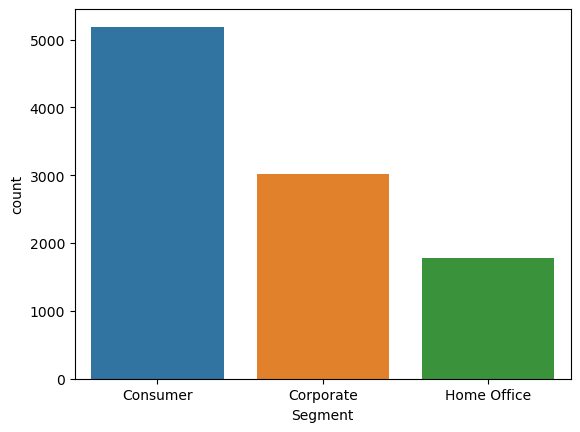

In [28]:
sns.countplot(x='Segment', data=dataset, palette='tab10')

In [29]:
customer_segment=dataset.groupby("Segment").sum()
customer_segment.reset_index(inplace=True)
customer_segment

/tmp/ipykernel_20/2203343737.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  customer_segment=dataset.groupby("Segment").sum()


,Segment,Postal Code,Sales,Quantity,Discount,Profit
0,Consumer,288785926,1.161158e+06,19519,820.91,134046.2612
1,Corporate,164536330,7.061464e+05,11608,477.85,91979.1340
2,Home Office,98157713,4.296531e+05,6744,262.33,60298.6785


In [30]:
customer_segment = dataset.groupby(['Segment'])[['Sales', 'Profit', 'Discount']].mean()

<Axes: ylabel='Profit'>

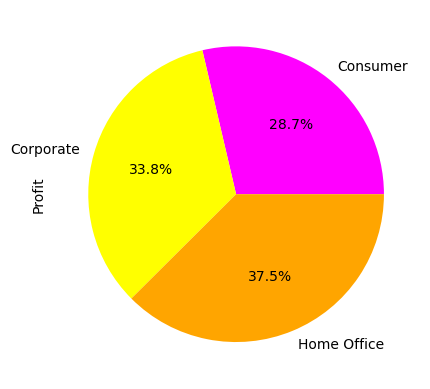

In [31]:
customer_segment["Profit"].plot(kind = 'pie', autopct='%1.1f%%', colors = ['magenta','yellow','orange','red'])

<Axes: ylabel='Sales'>

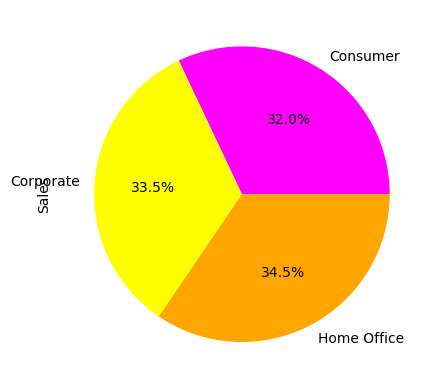

In [32]:
customer_segment["Sales"].plot(kind = 'pie', autopct='%1.1f%%', colors = ['magenta','yellow','orange','red'])

<Axes: ylabel='Discount'>

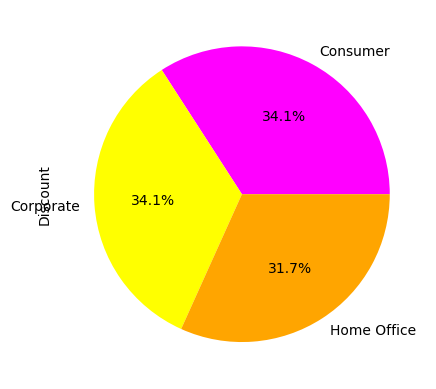

In [33]:
customer_segment["Discount"].plot(kind = 'pie', autopct='%1.1f%%', colors = ['magenta','yellow','orange','red'])

<Axes: xlabel='Segment'>

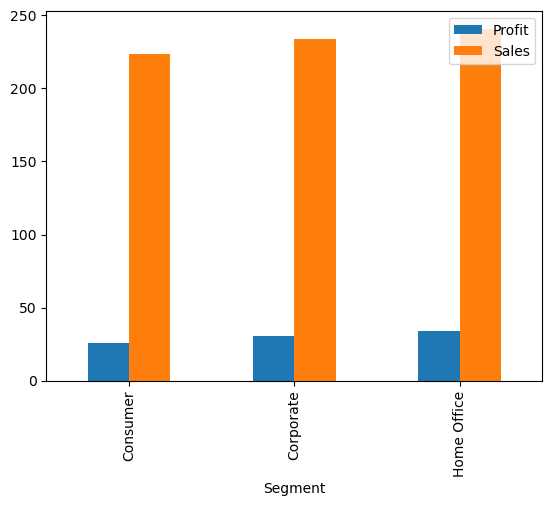

In [34]:
customer_segment.sort_values('Profit')[['Profit','Sales']].plot(kind='bar')

# 5. Region

In [35]:
dataset["Region"].value_counts()

West       3202
East       2848
Central    2323
South      1620
Name: Region, dtype: int64

In [36]:
profitable_region=pd.DataFrame(dataset.groupby("Region")["Profit"].sum())
profitable_region.reset_index(inplace=True)
profitable_region

,Region,Profit
0,Central,39706.3625
1,East,91522.7800
2,South,46749.4303
3,West,108345.5009


# 6. Ship mode

In [37]:
dataset["Ship Mode"].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

<Axes: xlabel='Ship Mode', ylabel='count'>

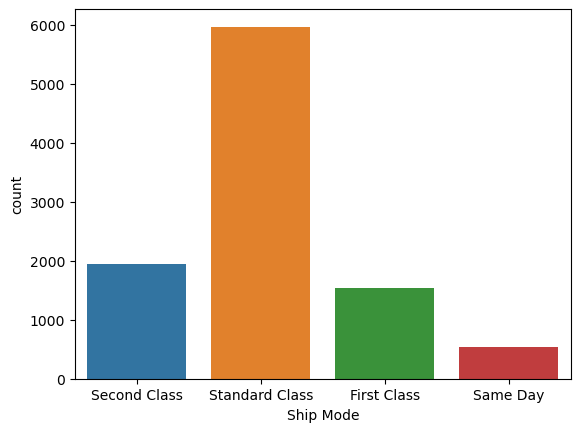

In [38]:
sns.countplot(x='Ship Mode', data=dataset, palette='tab10')

In [39]:
data_shipmode = dataset.groupby(['Ship Mode'])[['Sales', 'Profit', 'Discount']].mean()
data_shipmode

,Sales,Profit,Discount
Ship Mode,,,
First Class,228.497024,31.839948,0.164610
Same Day,236.396179,29.266591,0.152394
Second Class,236.085602,29.513214,0.138966
Standard Class,227.583067,27.494770,0.160023


<Axes: ylabel='Sales'>

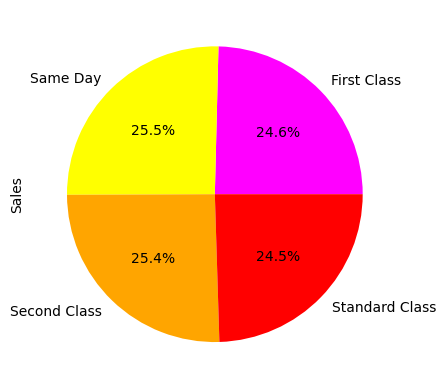

In [40]:
data_shipmode["Sales"].plot(kind = 'pie', autopct='%1.1f%%', colors = ['magenta','yellow','orange','red'])

<Axes: ylabel='Profit'>

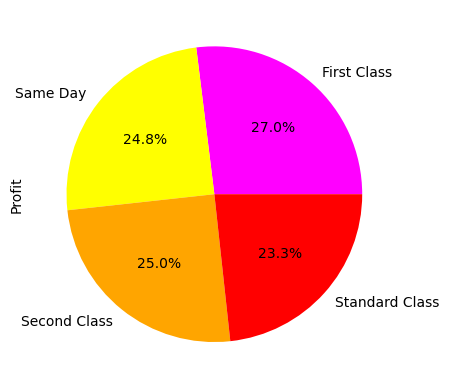

In [41]:
data_shipmode["Profit"].plot(kind = 'pie', autopct='%1.1f%%', colors = ['magenta','yellow','orange','red'])

<Axes: ylabel='Discount'>

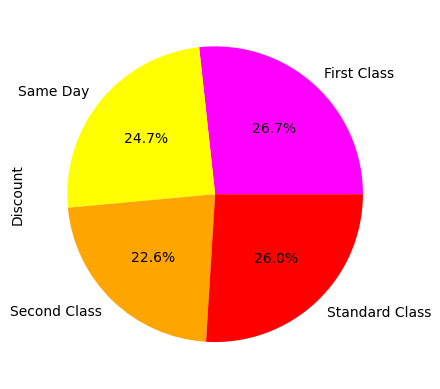

In [42]:
data_shipmode["Discount"].plot(kind = 'pie', autopct='%1.1f%%', colors = ['magenta','yellow','orange','red'])

<Axes: xlabel='Ship Mode'>

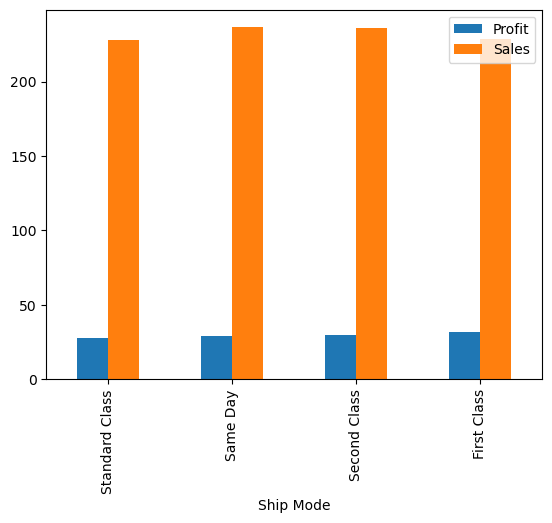

In [43]:
data_shipmode.sort_values('Profit')[['Profit','Sales']].plot(kind='bar')

# Analysis

In [44]:
dataset.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [45]:
dataset1=dataset.drop(columns=["Country","City","State","Sub-Category","Postal Code"])
dataset1.head()

,Ship Mode,Segment,Region,Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,South,Furniture,261.9600,2,0.00,41.9136
1,Second Class,Consumer,South,Furniture,731.9400,3,0.00,219.5820
2,Second Class,Corporate,West,Office Supplies,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,South,Furniture,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,South,Office Supplies,22.3680,2,0.20,2.5164


**Converting categorical variable into numerical value**

In [46]:
dataset1.replace({"Ship Mode":{"Standard Class":0,"Second Class":1,"First Class":2,"Same Day":3},"Segment":{"Consumer":0,"Corporate":1,"Home Office":2},
                 "Category":{"Office Supplies":0,"Furniture":1,"Technology":2},"Region":{"West":0,"East":1,"Central":2,"South":3}},inplace=True)

In [47]:
dataset1.head()

,Ship Mode,Segment,Region,Category,Sales,Quantity,Discount,Profit
0,1,0,3,1,261.9600,2,0.00,41.9136
1,1,0,3,1,731.9400,3,0.00,219.5820
2,1,1,0,0,14.6200,2,0.00,6.8714
3,0,0,3,1,957.5775,5,0.45,-383.0310
4,0,0,3,0,22.3680,2,0.20,2.5164


In [48]:
x=dataset1.iloc[:,:-1]
y=dataset1.iloc[:,-1]

**Spliting the dataset into training and testing data**

In [49]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=100)

**Model**

multiple linear regression

In [50]:
from sklearn.linear_model import LinearRegression
lr= LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [51]:
y_pred1= lr.predict(x_test)

In [52]:
lr.intercept_

43.25706560333812

In [53]:
lr.coef_

array([-1.34317701e+00, -1.20383360e+00,  2.83592971e+00, -1.41028369e+01,
        1.92464765e-01, -3.89183903e+00, -2.37020324e+02])

In [54]:
from sklearn.metrics import r2_score
print("R2 Score=",r2_score(y_pred1,y_test)*100)

R2 Score= -137.64813329204367


In [55]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred1)

26768.344997591605

(0.0, 3125.07784)

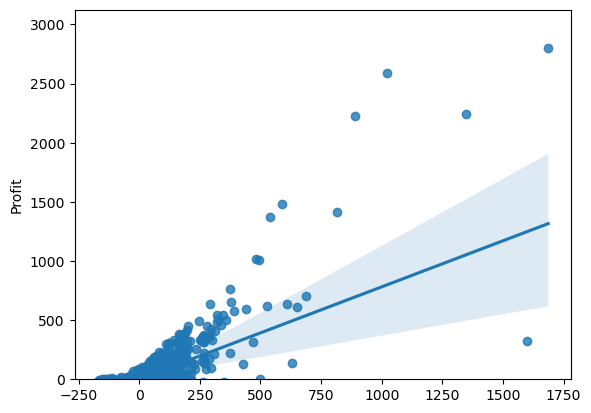

In [56]:
sns.regplot(x=y_pred1, y=y_test, data=dataset1)
plt.ylim(0,)

random forest

In [57]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(random_state=0,n_estimators=117)
model.fit(x_train,y_train)

RandomForestRegressor(n_estimators=117, random_state=0)

In [58]:
y_pred=model.predict(x_test)

In [59]:
from sklearn.metrics import r2_score
print("R2 Score=",r2_score(y_pred,y_test)*100)

R2 Score= 70.07355166675907


In [60]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)

8280.601989709483

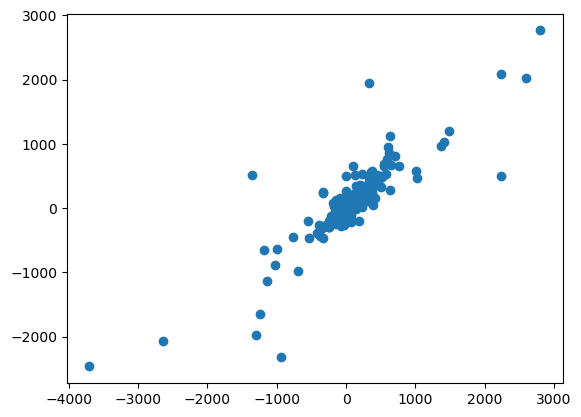

In [61]:
plt.scatter(y_test,y_pred)

(0.0, 3397.479160538934)

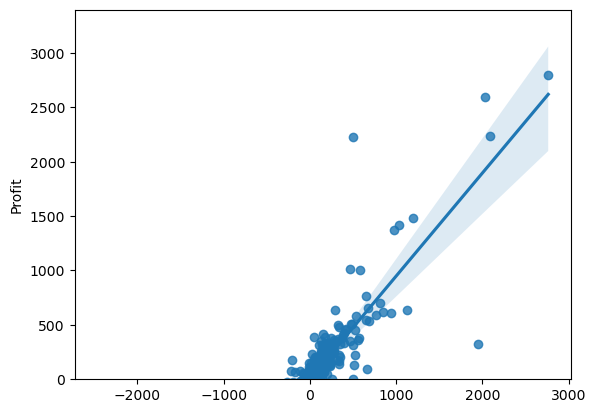

In [62]:
sns.regplot(x=y_pred, y=y_test, data=dataset1)
plt.ylim(0,)